In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_score, train_test_split, RandomizedSearchCV
from lightgbm import LGBMClassifier
from scipy.stats import randint, uniform, loguniform


In [3]:
from google.colab import drive

drive.mount('/content/drive')


Mounted at /content/drive


## Оглавление

**1. EDA**
- Target variable distribution
- Numerical features distribution
- Categorical features distribution
- Correlations, Outliers
- Share of Subscribed
- Share of Subscribed by age group
- Share of Subscribed by balance group
- Conclusions

**2. Modelling**

**3. SHAP analysis**
- SHAP-values
- Direction of feature effect
- Effect of top features

In [4]:
df_initial = pd.read_csv('/content/drive/MyDrive/bank-full.csv', sep=';')
df = df_initial.copy()

**Цель проекта:** определить клиентов, наиболее заинтересованных в оформлении депозита

Данные о 45211 клиентах банка. 17 признаков, из них 7 числовых признаков и 10 категориальных. y - целевая переменная (оформил ли клиент депозит). Пропущенных значений в данных нет.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [ ]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


# EDA


## Target variable distribution


В целевой переменной "Оформил ли клиент срочный депозит" наблюдается дисбаланс между двумя классами **no (88,3%), yes (11,7%)**.

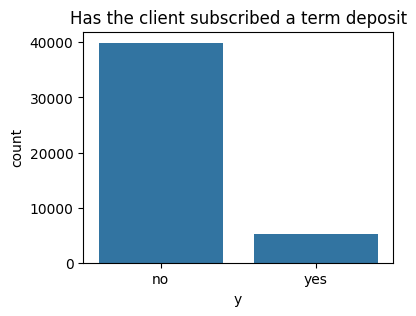

In [ ]:
plt.figure(figsize=(4, 3))
sns.countplot(df, x='y')
plt.title('Нas the client subscribed a term deposit')
plt.show()

In [ ]:
df['y'].value_counts(normalize=True) * 100

,proportion
y,
no,88.30152
yes,11.69848


## Numerical features distribution


In [ ]:
df['y'] = df['y'].map({'yes': 1, 'no': 0})

* Есть клиенты с отрицательным среднегодовым балансом. Это возможно, если банк разрешает уйти в минус. Это могут быть списания при недостатке средств (автоплатежи, проценты по кредиту). Есть также клиенты с очень большим балансом.
* Возможно, в разные дни месяца конверсия отличается. Это может быть связано с днями зарплаты.
* Среди клиентов, кто был в контакте более 7-8 минут, оформивших депозит больше, чем отказавшихся.






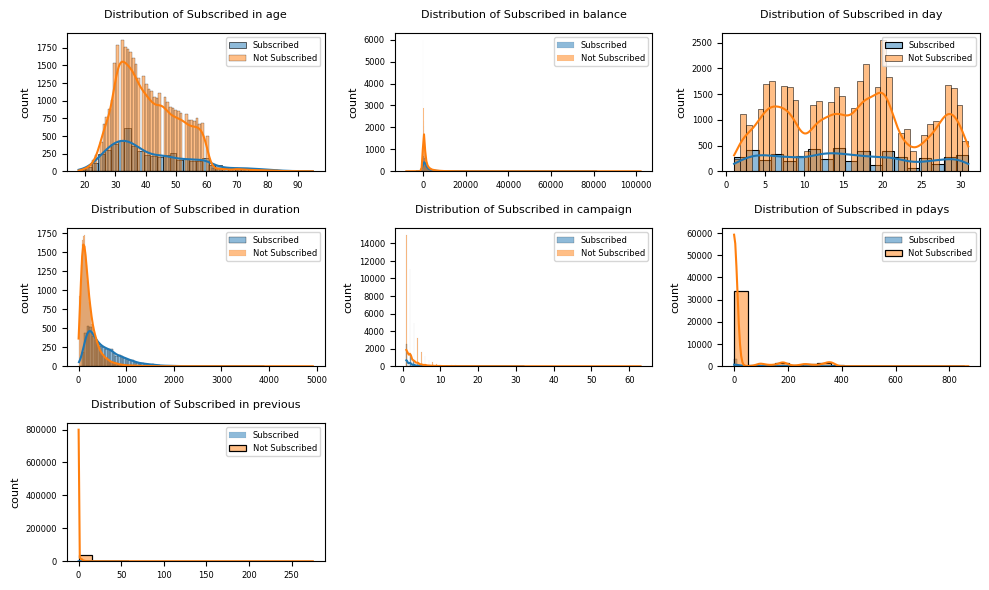

In [ ]:
num_features = [feat for feat in df.columns if (df[feat].dtype == 'int64') & (feat != 'y')]

fig, axs = plt.subplots(ncols=3, nrows=3, figsize=(10, 6))
axs = axs.flatten()

for i, col in enumerate(num_features):

    ax = axs[i]

    # Distribution of Subscribed in feature
    sns.histplot(
        df.loc[df['y'] == 1, col],
        label='Subscribed',
        ax=ax,
        kde=True,
    )
    sns.histplot(
        df.loc[df['y'] == 0, col],
        label='Not Subscribed',
        ax=ax,
        kde=True,
    )
    ax.set_xlabel('')
    ax.set_ylabel('count', size=8)
    ax.tick_params(axis='x', labelsize=6)
    ax.tick_params(axis='y', labelsize=6)
    ax.legend(loc='upper right', prop={'size': 6})
    ax.set_title(
    'Distribution of Subscribed in {}'.format(col), size=8, y=1.05
    )

for j in range(len(num_features), 9):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()


82% клиентов не участвовали в предыдущих маркетинговых кампаниях.

In [ ]:
df.loc[df['pdays'] == -1].shape[0] / df.shape[0]

0.8173674548229414

##Categorical features distribution

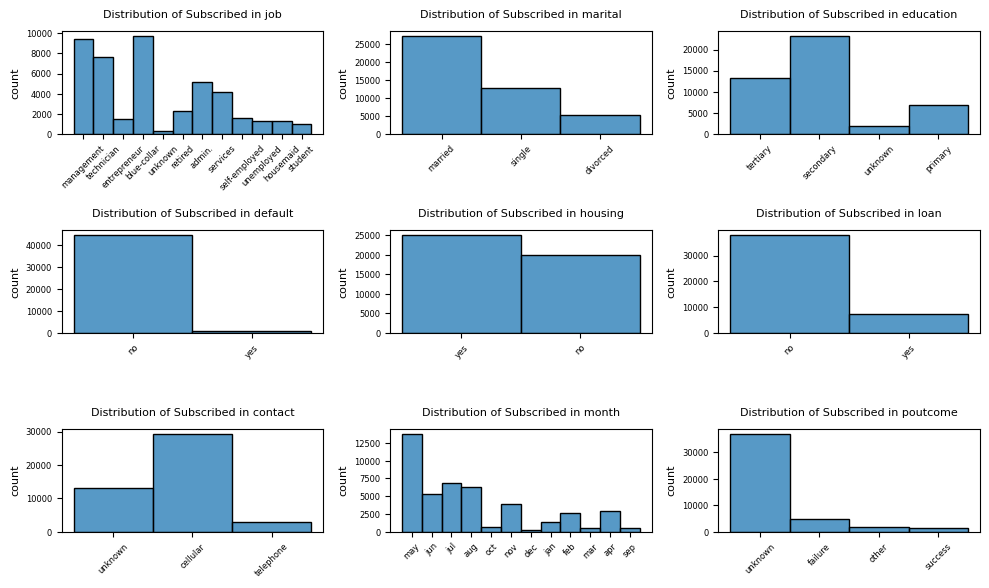

In [ ]:
cat_features = [feat for feat in df.columns if (df[feat].dtype == 'object')]

fig, axs = plt.subplots(ncols=3, nrows=3, figsize=(10, 6))
axs = axs.flatten()

for i, col in enumerate(cat_features):

    ax = axs[i]

    # Distribution of Subscribed in feature
    sns.histplot(
        df[col],
        ax=ax
    )

    ax.set_xlabel('')
    ax.set_ylabel('count', size=8)
    ax.tick_params(axis='x', labelsize=6, rotation=45)
    ax.tick_params(axis='y', labelsize=6)
    ax.set_title(
    'Distribution of Subscribed in {}'.format(col), size=8, y=1.05
    )

for j in range(len(cat_features), 9):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()


В признаке `job` больше всего клиентов относятся к категориям blue-collar, management и technician, тогда как student и housemaid представлены реже.
В признаке `marital` доминируют женатые (married) клиенты.
В `education` наиболее распространён уровень secondary, а значение unknown встречается редко.
Для признаков `default` и `loan` большинство клиентов не имеют просрочек и кредитов.
В признаке `housing` доли клиентов с жилищным кредитом и без него распределены относительно равномерно.
В `contact` чаще всего использовался способ связи cellular, а telephone встречается редко.
В признаке `month` наибольшее число контактов приходится на май.
В `poutcome` преобладает категория unknown, что указывает на отсутствие информации о результатах предыдущих кампаний.

##Correlations, Outliers

Умеренная связь между `duration` и целевой переменной. Это логично: если клиент заинтересован, он будет разговаривать дольше.

Умеренная связь между `pdays` и `previous`.

Хотя в основном признаки имеют слабую линейную зависимость с таргетом, это не значит, что эти признаки бесполезны. Деревья и бустинги могут использовать нелинейные зависимости.

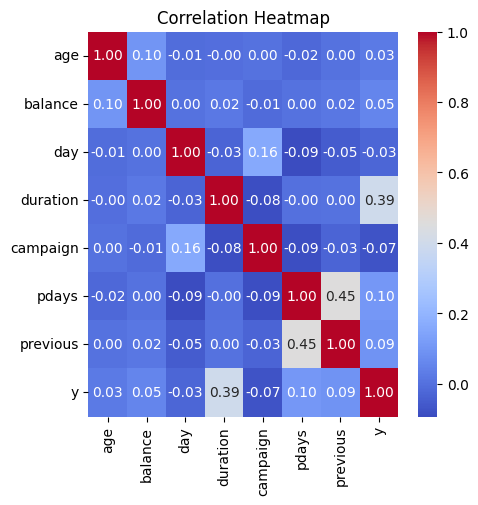

In [ ]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(5, 5))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

- Age: умеренная ассиметрия, есть выбросы (клиенты 70+).
- Balance: распределение сильно скошено, много экстремальных значений справа.
- Day: равномерное распределение без выбросов.


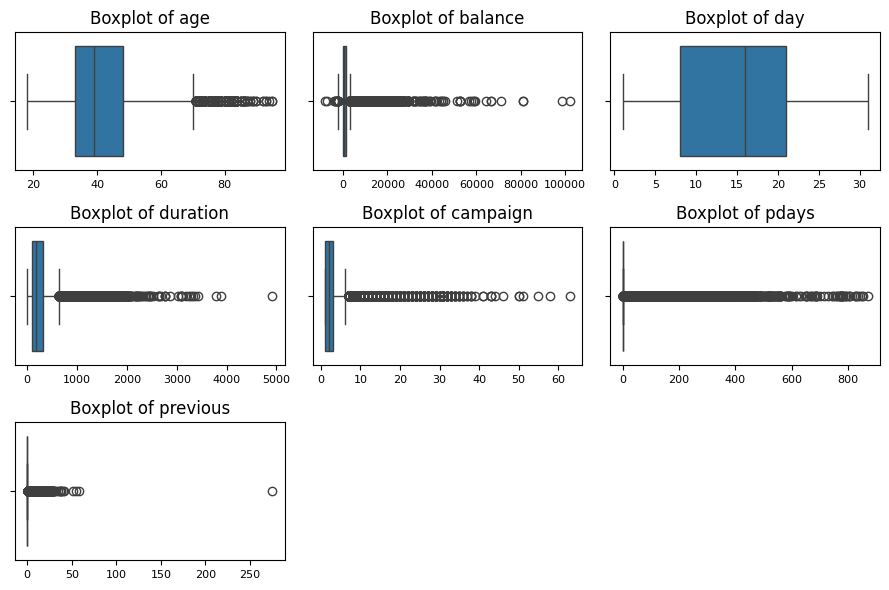

In [ ]:
fig, axs = plt.subplots(
    nrows=3,
    ncols=3,
    figsize=(9, 6)
)

axs = axs.flatten()

for i, col in enumerate(num_features):

    sns.boxplot(
        x=df[col],
        ax=axs[i]
    )

    axs[i].set_title(f'Boxplot of {col}')
    axs[i].set_xlabel('')
    axs[i].tick_params(axis='x', labelsize=8)

for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()

## Share of Subscribed


- Чаще всего депозит оформляют пенсионеры и студенты, 23% и 29% соответственно. Реже всего - blue-collar, entrepreneur, hosemaid, services - 7-9%.
- Состоящие в браке реже оформляют депозит (10%), чем те, кто в браке не был (15%).
- Люди с начальным образованием реже оформляют депозит, а люди с высшим образованием - чаще.
- Люди с просроченным кредитом в два раза реже оформляют депозит.
- Те, у кого есть ипотека или потребительский кредит реже оформляют депозит.
- Самая высокая конверсия в марте, сентябре, октябре и декабре 44-52%. Самая низкая - летом, в мае, ноябре и январе - 7-11%.
- Конверсия среди клинетов, кто оформил депозит в предыдущую кампанию, значительно выше (65%), чем среди тех, кто отказался (13%).


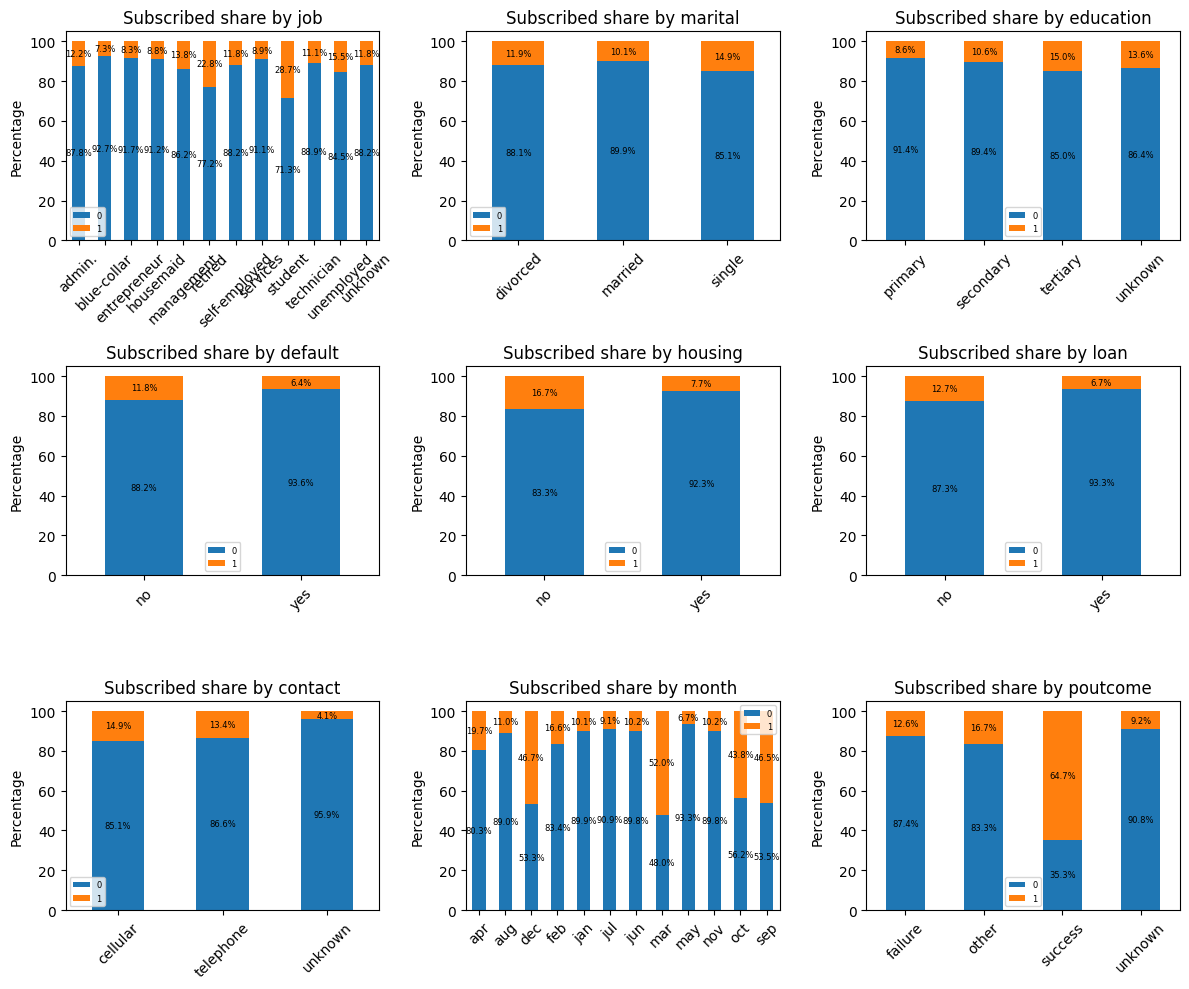

In [ ]:
fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(12, 10))
axs = axs.flatten()

cat_features = [
    feat for feat in df.columns if (df[feat].dtype == 'object')
]

for i, feat in enumerate(cat_features):

    ct = pd.crosstab(df[feat], df['y'], normalize='index') * 100

    ax = axs[i]
    ct.plot(kind='bar', stacked=True, ax=ax)

    ax.set_title(f'Subscribed share by {feat}')
    ax.set_ylabel('Percentage')
    ax.set_xlabel('')
    ax.legend(title='', prop={'size': 6})

    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', label_type='center', fontsize=6)

    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

##Share of Subscribed by age group

Среди молодых клиентов (до 30 лет) и старшего поколения (50+) наблюдается самая высокая конверсия 15-16%. У молодых людей растущий доход и меньше обязательств. Старшее поколение имеет накопления, меньше склонность к финансовому риску. Люди среднего возраста (40-50 лет) наимее склонны к открытию депозита (конверсия около 9%). Это может быть связано с высокой финансовой нагрузкой (ипотека, расходы на семью).

Клиенты без кредита чаще оформляют депозит, чем клиенты с кредитом. Молодые клиенты до 30 лет без кредита открывают депозит с вероятностью более 25%. Клиенты 50+ без кредита открывают депозит с вероятностью более 25%.открывают депозит с вероятностью около 22%.

Наиболее высокая вероятность оформления депозита наблюдается среди молодых и пожилых клиентов, тогда как клиенты среднего возраста демонстрируют минимальную склонность к подписке. Вероятно, это связано с различиями в финансовой нагрузке и целях накопления на разных этапах жизни.

Обнаружена нелинейная зависимость между возрастом и вероятностью оформления депозита.

In [ ]:
df['has_credit'] = ((df['loan'] == 'yes') | (df['housing'] == 'yes')).map({True: 'yes', False: 'no'})
# df['has_credit'].unique()

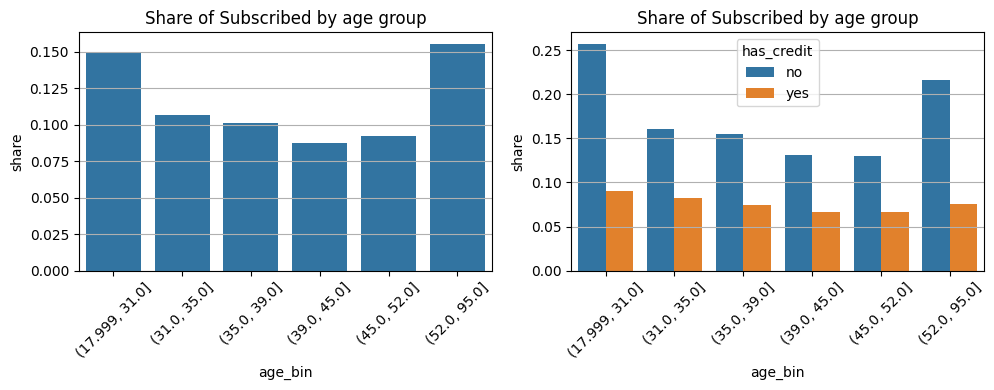

In [ ]:
df['age_bin'] = pd.qcut(df['age'], q=6)
age_target_rate1 = df.groupby('age_bin', observed=True)['y'].mean()
age_target_rate2 = df.groupby(['age_bin', 'has_credit'], observed=True)['y'].mean().reset_index()

fig, axs = plt.subplots(1, 2, figsize=(10, 4))

sns.barplot(
    x=age_target_rate1.index,
    y=age_target_rate1.values,
    ax=axs[0]
)

sns.barplot(
    data=age_target_rate2,
    x='age_bin',
    y='y',
    hue='has_credit',
    ax=axs[1]
)

for i in range(len(axs)):

    axs[i].set_title('Share of Subscribed by age group')
    axs[i].set_ylabel('share')
    axs[i].tick_params(axis='x', rotation=45)
    axs[i].grid(True, axis='y')

plt.tight_layout()
plt.show()

##Share of Subscribed by balance group

Разделим клиентов по среднегодовому балансу, чтобы посмотреть есть связь между балансом и вероятностью оформления депозита. Чтобы корректно сранивать группы, нужно привести их к одному размеру. Сначала выделим клинетов с отрицательным балансом, затем разделим клиентов с положительным балансом на примерно равные группы.

Клиенты с высоким балансом чаще оформляют депозит. Клиенты с отрицательным или нулевым балансом значительно реже оформляют депозит.

Клиенты с положительным балансом - конверсия 12,6%
Клиенты с отрицательным балансом - конверсия 6,9%

Это логично: у клиента есть свободные деньги; выше финансовая стабильность; выше склонность к накоплению



Вероятность оформления депозита положительно связана с уровнем среднегодового баланса клиента. Наиболее высокая конверсия наблюдается у клиентов с balance > 2200, тогда как клиенты с отрицательным или нулевым балансом демонстрируют минимальную склонность к открытию депозита. Это указывает на сильную связь между финансовой стабильностью клиента и вероятностью подписки на депозитный продукт.

In [ ]:
negative_balance = df.loc[df['balance'] <= 0, 'balance']
positive_balance = df.loc[df['balance'] > 0, 'balance']

pos_balance_bin = pd.qcut(positive_balance, q=5)

print(f'Size of positive balance groups {pos_balance_bin.value_counts().values}\n\
Size of negative balance group {negative_balance.shape[0]}')

Size of positive balance groups [7603 7586 7583 7582 7577]
Size of negative balance group 7280


In [ ]:
df['balance_bin'] = pos_balance_bin
df['balance_bin'] = df['balance_bin'].cat.add_categories(['Отрицательный/Нулевой'])
df.loc[df['balance'] <= 0, 'balance_bin'] = 'Отрицательный/Нулевой'
# df.loc[df['balance_bin'].isna(), 'balance_bin']

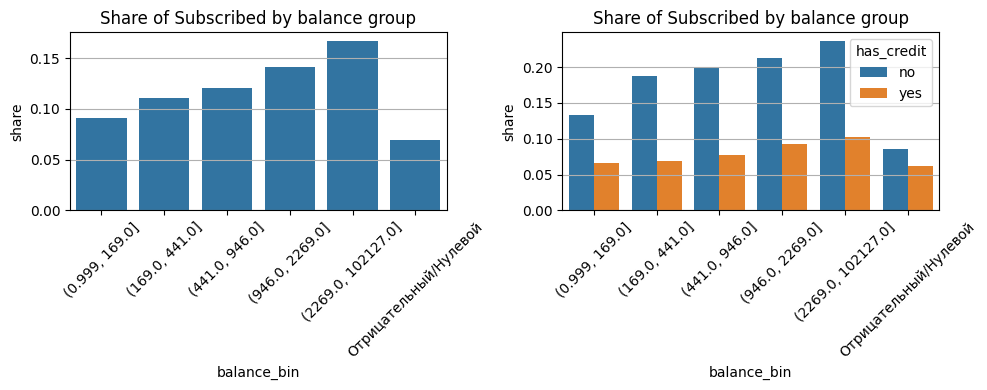

In [ ]:
balance_target_rate1 = df.groupby('balance_bin', observed=True)['y'].mean()
balance_target_rate2 = df.groupby(['balance_bin', 'has_credit'], observed=True)['y'].mean().reset_index()

fig, axs = plt.subplots(1, 2, figsize=(10, 4))

sns.barplot(
    x=balance_target_rate1.index,
    y=balance_target_rate1.values,
    ax=axs[0]
)

sns.barplot(
    data=balance_target_rate2,
    x='balance_bin',
    y='y',
    hue='has_credit',
    ax=axs[1]
)

for i in range(len(axs)):

    axs[i].set_title('Share of Subscribed by balance group')
    axs[i].set_ylabel('share')
    axs[i].tick_params(axis='x', rotation=45)
    axs[i].grid(True, axis='y')

plt.tight_layout()
plt.show()

In [ ]:
share_pos_balance = df.loc[(df['balance'] > 0) & (df['y'] == 1)].shape[0] / df.loc[df['balance'] > 0].shape[0]
share_neg_balance = df.loc[(df['balance'] <= 0) & (df['y'] == 1)].shape[0] / df.loc[df['balance'] <= 0].shape[0]

print(f'Share of Subscribed with positive balance: {round(share_pos_balance, 3)}\n\
Share of Subscribed with negative balance or zero: {round(share_neg_balance, 3)}')

Share of Subscribed with positive balance: 0.126
Share of Subscribed with negative balance or zero: 0.069


##Conclusions

Клиенты с положительным балансом оформляют депозиты в 1,8 раза чаще (конверсия 12,6% против 6,9%), чем клиенты с отрицательным или нулевым балансом.

*Маркетинговые кампании по депозитарным продуктам должны быть в первую очередь нацелены на сегменты с высоким и стабильным доходом. Клиентам с отрицательным балансом предлагать стандартные депозиты неэффективно.*

Конверсия среди молодых (до 30 лет) и пожилых (50+) клиентов составляет 15–16%, в то время как у людей среднего возраста (30–50 лет) она падает до 9%. У клиентов без кредитных обязательств конверсия выше.

*Целевая аудитория - младше 30 лет и старше 50. Для клиентов среднего возраста (30-50) искать специализированные предложения для повышения конверсии.*

Самая высокая конверсия у студентов (29%) и пенсионеров (23%). Самая низкая — у blue-collar, предпринимателей, домохозяек и работников сферы услуг (7–9%). Высшее образование коррелирует с более высокой склонностью к депозитам.

*Для сегментов с низкой конверсией (blue-collar, услуги) необходимо упрощать продукт, делать его более доступным по сумме входа.*

Конверсия выше после 7–8 минут разговора. Пик оформления приходится на март, сентябрь, октябрь и декабрь (44–52%), а провал — на лето, май, ноябрь и январь (7–11%).

*Проводить маркетинговый кампании в периоды высокой конверсии (начало весны, осень, конец года). В периоды спада (лето, январь) можно снижать активность.*

Клиенты, оформившие депозит в прошлый раз, делают это снова с вероятностью 65%. Те, кто отказался, — лишь в 13% случаев.

*Необходимо в первую очередь проводить повторные кампании среди тех, кто уже является клиентом банка по депозитным продуктам. Это самый дешёвый и эффективный способ привлечения средств.*

<a id="modelling"></a>

# Modelling


Для предсказания будем использовать алгоритм градиентного бустинга над деревьями решений LightGBM. Он хорошо работает со структурированными табличными данными, эффективно обрабатывает нелинейные отношения и категориальные функции, устойчив к выбросам и обеспечивает высокую производительность прогнозирования для задач двоичной классификации.

Длительность звонка `duration` становится известна только после того, как звонок уже произошёл. Использование данного признака в модели может приводить к утечке данных и нереалистично завышать качество модели. Обычно короткие разговоры связаны с отсутствием интереса клиента, тогда как более длительные звонки чаще заканчиваются оформлением депозита. Поэтому удаляем этот признак.

In [5]:
def prepare_categorical_features(X_train, X_test):

    cat_cols = X_train.select_dtypes(
        include=['object', 'category']
    ).columns

    for col in cat_cols:

        X_train[col] = (
            X_train[col]
            .astype(str)
            .astype('category')
        )

        X_test[col] = (
            X_test[col]
            .astype(str)
            .astype('category')
            .cat.set_categories(X_train[col].cat.categories)
        )

    return X_train, X_test

Функция для добавления новых признаков.

In [6]:
def add_features(X):

    X['has_credit'] = ((X['loan'] == 'yes') | (X['housing'] == 'yes')).map({True: 'yes', False: 'no'})
    X['was_contacted_before'] = (X['pdays'] != -1).map({True: 'yes', False: 'no'})

    X['age_group'] = pd.cut(X['age'], bins=[-float('inf'), 30, 50, float('inf')], labels=['18-30', '30-50', '50+'], right=False)
    X['balance_group'] = pd.cut(X['balance'], bins=[-float('inf'), 0, 500, 3000, float('inf')], labels=['negative', 'low', 'middle', 'high'], right=False)

    X['age_bal_group'] = X['age_group'].astype(str) + '-' + X['balance_group'].astype(str)
    X['age_credit_group'] = X['age_group'].astype(str) + '-' + X['has_credit'].astype(str)

    return X

Обучим модель на исходных данных и с добавлением новых признаков. После обучения сравним модели по roc_auc score и выберем модель с лучшей оценкой.

In [7]:
def prepare_baseline(df):

    y = df['y'].map({'no': 0, 'yes': 1})
    X = df.drop(columns=['y', 'duration'])

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        stratify=y,
        random_state=42
    )

    X_train, X_test = prepare_categorical_features(X_train, X_test)

    return X_train, X_test, y_train, y_test

In [8]:
def prepare_feature_engineering(df):

    y = df['y'].map({'no': 0, 'yes': 1})
    X = df.drop(columns=['y', 'duration'])

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        stratify=y,
        random_state=42
    )

    X_train = add_features(X_train)
    X_test = add_features(X_test)

    X_train, X_test = prepare_categorical_features(X_train, X_test)

    return X_train, X_test, y_train, y_test


In [9]:
# Baseline
X_train_base, X_test_base, y_train_base, y_test_base = prepare_baseline(df_initial)

# Feature Engineering
X_train_fe, X_test_fe, y_train_fe, y_test_fe = prepare_feature_engineering(df_initial)

In [10]:
model_base = LGBMClassifier(class_weight="balanced", random_state=42, verbosity=-1)

param_dist = {
    "num_leaves": randint(10, 80),
    "max_depth": randint(3, 9),
    "learning_rate": loguniform(0.01, 0.2),
    "n_estimators": randint(200, 1000),
    "min_child_samples": randint(20, 200),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
    "reg_alpha": loguniform(1e-4, 10),
    "reg_lambda": loguniform(1e-4, 10)
}

# Randomized Search CV for finding the best parameters under roc_auc scoring

lgbm_cv_base = RandomizedSearchCV(model_base,
                             param_distributions=param_dist,
                             n_iter=10,
                             cv=5,
                             scoring='roc_auc',
                             random_state=42,
                             verbose=2
)

lgbm_cv_base.fit(X_train_base, y_train_base)

print('BASELINE')
print("Best params:", lgbm_cv_base.best_params_)
print("Best score:", lgbm_cv_base.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END colsample_bytree=0.749816047538945, learning_rate=0.17254716573280354, max_depth=5, min_child_samples=91, n_estimators=900, num_leaves=30, reg_alpha=0.0006026889128682511, reg_lambda=0.000602521573620386, subsample=0.6232334448672797; total time=   3.6s
[CV] END colsample_bytree=0.749816047538945, learning_rate=0.17254716573280354, max_depth=5, min_child_samples=91, n_estimators=900, num_leaves=30, reg_alpha=0.0006026889128682511, reg_lambda=0.000602521573620386, subsample=0.6232334448672797; total time=   6.2s
[CV] END colsample_bytree=0.749816047538945, learning_rate=0.17254716573280354, max_depth=5, min_child_samples=91, n_estimators=900, num_leaves=30, reg_alpha=0.0006026889128682511, reg_lambda=0.000602521573620386, subsample=0.6232334448672797; total time=   3.5s
[CV] END colsample_bytree=0.749816047538945, learning_rate=0.17254716573280354, max_depth=5, min_child_samples=91, n_estimators=900, num_leaves=30, re

In [11]:
model_fe = LGBMClassifier(class_weight="balanced", random_state=42, verbosity=-1)

param_dist = {
    "num_leaves": randint(10, 80),
    "max_depth": randint(3, 9),
    "learning_rate": loguniform(0.01, 0.2),
    "n_estimators": randint(200, 1000),
    "min_child_samples": randint(20, 200),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
    "reg_alpha": loguniform(1e-4, 10),
    "reg_lambda": loguniform(1e-4, 10)
}

# Randomized Search CV for finding the best parameters under roc_auc scoring

lgbm_cv_fe = RandomizedSearchCV(model_fe,
                             param_distributions=param_dist,
                             n_iter=10,
                             cv=5,
                             scoring='roc_auc',
                             random_state=42,
                             verbose=2
)

lgbm_cv_fe.fit(X_train_fe, y_train_fe)

print('FE')
print("Best params:", lgbm_cv_fe.best_params_)
print("Best score:", lgbm_cv_fe.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END colsample_bytree=0.749816047538945, learning_rate=0.17254716573280354, max_depth=5, min_child_samples=91, n_estimators=900, num_leaves=30, reg_alpha=0.0006026889128682511, reg_lambda=0.000602521573620386, subsample=0.6232334448672797; total time=   3.9s
[CV] END colsample_bytree=0.749816047538945, learning_rate=0.17254716573280354, max_depth=5, min_child_samples=91, n_estimators=900, num_leaves=30, reg_alpha=0.0006026889128682511, reg_lambda=0.000602521573620386, subsample=0.6232334448672797; total time=   4.7s
[CV] END colsample_bytree=0.749816047538945, learning_rate=0.17254716573280354, max_depth=5, min_child_samples=91, n_estimators=900, num_leaves=30, reg_alpha=0.0006026889128682511, reg_lambda=0.000602521573620386, subsample=0.6232334448672797; total time=   4.4s
[CV] END colsample_bytree=0.749816047538945, learning_rate=0.17254716573280354, max_depth=5, min_child_samples=91, n_estimators=900, num_leaves=30, re

In [12]:
print(f'CV_ROC_AUC baseline model: {lgbm_cv_base.best_score_}')
print(f'CV_ROC_AUC feature engineering model: {lgbm_cv_fe.best_score_}')

CV_ROC_AUC baseline model: 0.8012942756752516
CV_ROC_AUC feature engineering model: 0.8003936557335214


In [13]:
TEST_ROC_AUC_BASE = roc_auc_score(
                                  y_test_base,
                                  lgbm_cv_base.best_estimator_.predict_proba(X_test_base)[:, 1]
)

TEST_ROC_AUC_FE = roc_auc_score(
                                y_test_fe,
                                lgbm_cv_fe.best_estimator_.predict_proba(X_test_fe)[:, 1]
)

In [14]:
print(f'TEST_ROC_AUC baseline model: {TEST_ROC_AUC_BASE}')
print(f'TEST_ROC_AUC feature engineering model: {TEST_ROC_AUC_FE}')

TEST_ROC_AUC baseline model: 0.8067526778115395
TEST_ROC_AUC feature engineering model: 0.8058056635018638


Новые признаки не улучшили ROC-AUC. Одна из возможных причин заключается в том, что LightGBM уже способен фиксировать нелинейные отношения и взаимодействия непосредственно из исходных переменных.

Базовая LightGBM показала немного более высокое качество, чем модель с feature engineering: CV ROC-AUC 0.8013 против 0.8004, test ROC-AUC 0.8068 против 0.8058.


<a id="shap-analysis"></a>

# SHAP analysis

SHAP помогает интерпретировать модель через вклад каждого признака в прогноз. Для анализа берем модель с лучшим roc_auc score на тесте.

In [15]:
best_model = lgbm_cv_base.best_estimator_
X_train_selected = X_train_base
X_test_selected = X_test_base
y_train_selected = y_train_base
y_test_selected = y_test_base

## SHAP-values

`mean_abs_shap` показывает среднюю силу влияния признака на прогноз модели. Чем выше значение, тем сильнее признак влияет на вероятность класса `yes`.


In [16]:
shap_sample_size = X_test_selected.shape[0]
X_shap = X_test_selected.sample(n=shap_sample_size, random_state=42)

explainer = shap.TreeExplainer(best_model)
shap_values_raw = explainer.shap_values(X_shap)

if isinstance(shap_values_raw, list):
    shap_values = shap_values_raw[1]
elif hasattr(shap_values_raw, 'values'):
    shap_values = shap_values_raw.values
    if shap_values.ndim == 3:
        shap_values = shap_values[:, :, 1]
else:
    shap_values = shap_values_raw

shap_importance = (
    pd.DataFrame({
        'feature': X_shap.columns,
        'mean_abs_shap': np.abs(shap_values).mean(axis=0)
    })
    .sort_values('mean_abs_shap', ascending=False)
    .reset_index(drop=True)
)

shap_importance['importance_share_%'] = (
    shap_importance['mean_abs_shap']
    / shap_importance['mean_abs_shap'].sum()
    * 100
)

display(shap_importance.head(20))


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


,feature,mean_abs_shap,importance_share_%
0,contact,0.415918,21.237954
1,month,0.296672,15.148928
2,day,0.174237,8.897040
3,balance,0.163819,8.365068
4,marital,0.149266,7.621929
5,poutcome,0.142772,7.290356
6,housing,0.141753,7.238296
7,age,0.108747,5.552926
8,campaign,0.094703,4.835790
9,pdays,0.068590,3.502423


Наиболее важным признаком оказался `contact` — тип связи с клиентом оказывает наибольшее влияние на предсказания модели. Признаки `month` и `day` также имеют высокую важность, что говорит о сильном влиянии времени контакта на вероятность подписки. Признак `balance` остаётся одним из наиболее значимых финансовых факторов, однако его влияние ниже, чем у характеристик коммуникации.
Среди демографических признаков наиболее важными являются `marital` и `age`, тогда как `education` и `job` оказывают более слабое влияние.
Признаки, связанные с предыдущими маркетинговыми взаимодействиями (`poutcome`, `campaign`, `pdays`, `previous`), в совокупности оказывают заметное влияние на модель, что подтверждает важность истории контактов с клиентом.
Признак `default` практически не влияет на предсказания модели, следовательно, наличие просроченного кредита не является значимым фактором для данной модели.

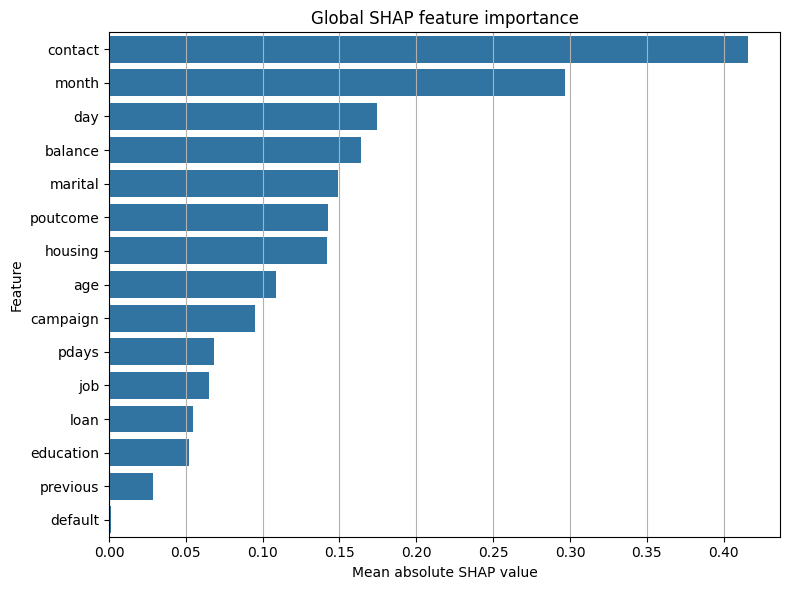

In [17]:
plt.figure(figsize=(8, 6))
plot_data = shap_importance.sort_values('mean_abs_shap', ascending=False)

sns.barplot(
    data=plot_data,
    x='mean_abs_shap',
    y='feature',
)

plt.title('Global SHAP feature importance')
plt.xlabel('Mean absolute SHAP value')
plt.ylabel('Feature')
plt.grid(True, axis='x')

plt.tight_layout()
plt.show()


## Direction of feature effect

Bar plot показывает только силу влияния. Summary plot ниже добавляет направление: точки справа увеличивают вероятность оформления депозита, точки слева уменьшают ее. Цвет показывает значение признака: для числовых признаков это низкие/высокие значения, для категориальных признаков используется внутренний код категории только для визуализации.


Большие значения `balance` и `age` чаще связаны с положительным влиянием на вероятность подписки.
Высокие значения `campaign` в основном снижают вероятность положительного исхода, что может указывать на негативный эффект слишком большого количества контактов.

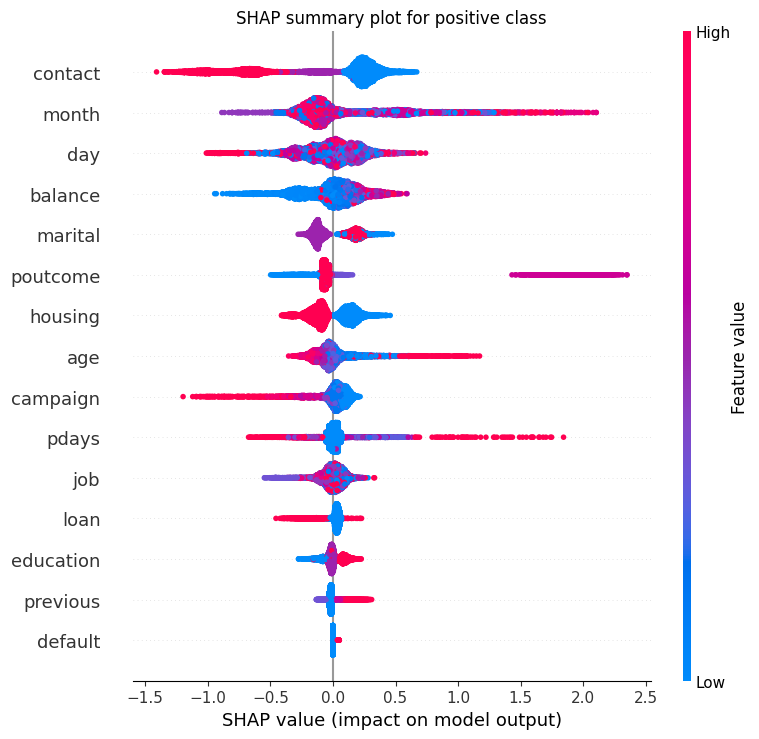

In [18]:
def make_shap_plot_data(X):
    X_plot = X.copy()

    categorical_cols = X_plot.select_dtypes(include=['object', 'category']).columns
    for col in categorical_cols:
        X_plot[col] = X_plot[col].astype('category').cat.codes

    return X_plot

X_shap_plot = make_shap_plot_data(X_shap)

shap.summary_plot(
    shap_values,
    X_shap_plot,
    max_display=15,
    show=False
)

plt.title('SHAP summary plot for positive class')
plt.tight_layout()
plt.show()


## Effect of top features

Для числовых признаков строим dependence plots: они показывают, как изменение значения признака связано с SHAP-вкладом. Для категориальных признаков строим boxplot по категориям, потому что числовой код категории не имеет самостоятельного бизнес-смысла.


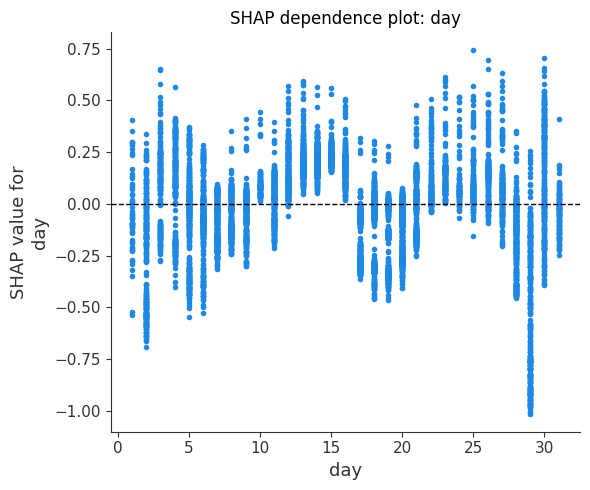

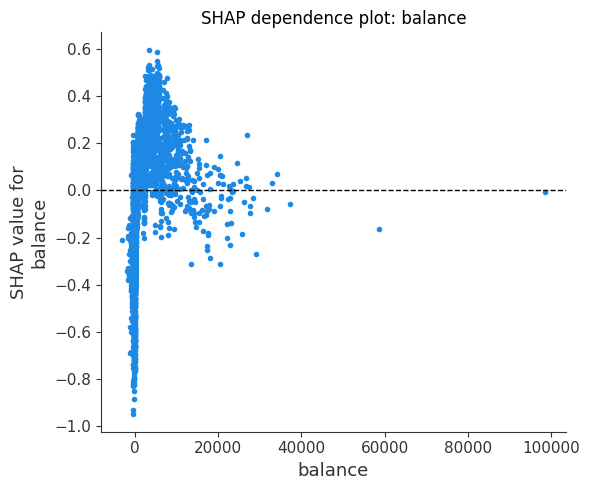

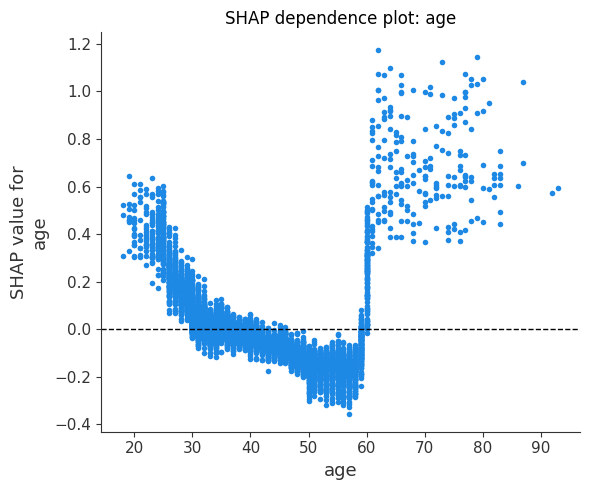

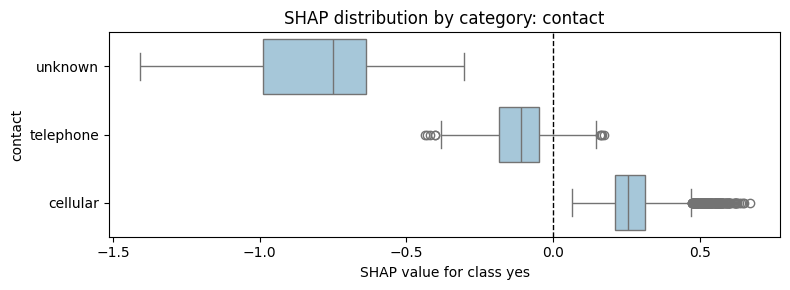

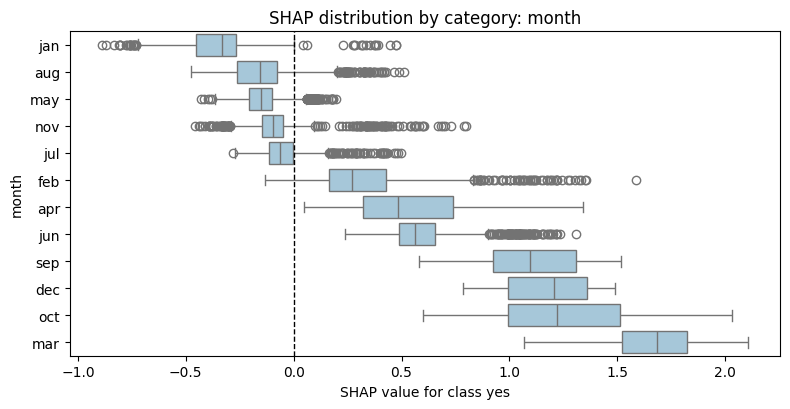

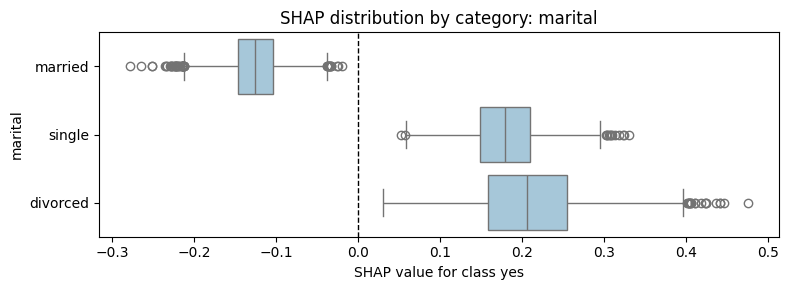

In [19]:
top_numeric_features = [
    feature
    for feature in shap_importance['feature']
    if feature in X_shap.select_dtypes(include='number').columns
]

top_categorical_features = [
    feature for feature in shap_importance['feature']
    if feature not in top_numeric_features
]

for feature in top_numeric_features[:3]:
    shap.dependence_plot(
        feature,
        shap_values,
        X_shap_plot,
        interaction_index=None,
        show=False
    )

    plt.axhline(0, color='black', linestyle='--', linewidth=1)
    plt.title(f'SHAP dependence plot: {feature}')

    plt.tight_layout()
    plt.show()

for feature in top_categorical_features[:3]:
    feature_position = X_shap.columns.get_loc(feature)
    category_shap = pd.DataFrame({
        feature: X_shap[feature].astype(str),
        'shap_value': shap_values[:, feature_position]
    })

    category_order = (
        category_shap
        .groupby(feature)['shap_value']
        .median()
        .sort_values()
        .index
    )

    plt.figure(figsize=(8, max(3, 0.35 * category_shap[feature].nunique())))
    sns.boxplot(
        data=category_shap,
        x='shap_value',
        y=feature,
        order=category_order,
        color='#9ECAE1'
    )

    plt.axvline(0, color='black', linestyle='--', linewidth=1)
    plt.title(f'SHAP distribution by category: {feature}')
    plt.xlabel('SHAP value for class yes')
    plt.ylabel(feature)

    plt.tight_layout()
    plt.show()


Видна нелинейная зависимость от дня месяца. В середине месяца и около 25 числа лучшее влияние на положительный исход.

Увеличение баланса увеличивает вероятность положительного исхода.

Клиенты до 30 лет и после 60 повышают вероятность положительного исхода в модели.

Модель считает мобильную связь наиболее благоприятным способом контакта с клиентом. Категория unknown оказывает сильное отрицательное влияние на предсказание и снижает вероятность положительного исхода.

Месяцы mar, oct, dec и sep имеют наиболее положительное влияние на вероятность подписки. Месяцы jan и aug чаще дают отрицательные SHAP values и связаны с меньшей вероятностью отклика. Видно, что временной фактор существенно влияет на предсказания модели, что может отражать сезонность маркетинговых кампаний и поведение клиентов в разные периоды года.

Разведенные и неженатые оказывают небольшое положительное влияние на предсказание положительного исхода, тогда как состоящие в браке - небольшое отрицательное.

- Основные факторы прогноза связаны со способом и временем контакта: `contact`, `month` и `day` дают около 45% суммарной SHAP-важности.
- Среди характеристик клиента заметны `balance`, `marital`, `housing` и `age`: более высокие значения `balance` и `age` чаще повышают вероятность подписки.
- Большое число контактов (`campaign`) скорее снижает вероятность положительного исхода, а `default` почти не влияет на предсказания модели.